
# PCA Notebook

This notebook uses a toy housing dataset designed so that:

The features are:

- Number of Bedrooms
- Number of Bathrooms
- Square Footage
- Number of Schools within 5 miles
- Crime Rate as a value from 1 (low crime) to 10 (high crime)


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


## 1. Create the dataset

In [3]:
data = pd.DataFrame({
    #"House": ["H1","H2","H3","H4","H5","H6","H7","H8","H9","H10"],
    "Bedrooms": [1,2,3,4,5,6,7,8,9,10],
    "Bathrooms": [1,2,2.5,3,3,3,4,4,4,4],
    "SquareFootage": [540.62,989.74,1503.97,2015.85,2477.78,2997.11,3501.45,3987.54,4506.00,4991.38],
    "SchoolsNearby": [5,1,9,2,8,3,7,4,6,10],
    "CrimeRate": [6,10,2,9,3,8,4,7,5,1]
})

print(data.set_index(pd.Index([f"H{i+1}" for i in range(len(data))])))


     Bedrooms  Bathrooms  SquareFootage  SchoolsNearby  CrimeRate
H1          1        1.0         540.62              5          6
H2          2        2.0         989.74              1         10
H3          3        2.5        1503.97              9          2
H4          4        3.0        2015.85              2          9
H5          5        3.0        2477.78              8          3
H6          6        3.0        2997.11              3          8
H7          7        4.0        3501.45              7          4
H8          8        4.0        3987.54              4          7
H9          9        4.0        4506.00              6          5
H10        10        4.0        4991.38             10          1



## 2. Lets look at some plots where we pick two features and try to see their relationship. 




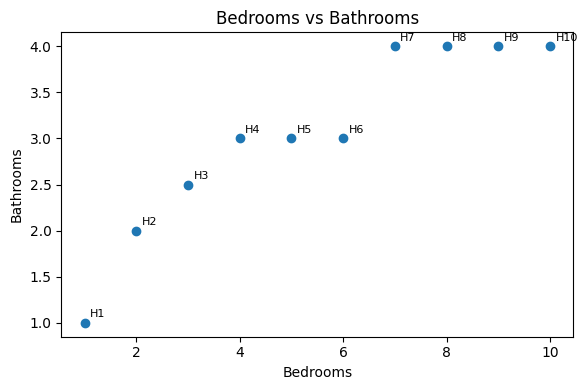

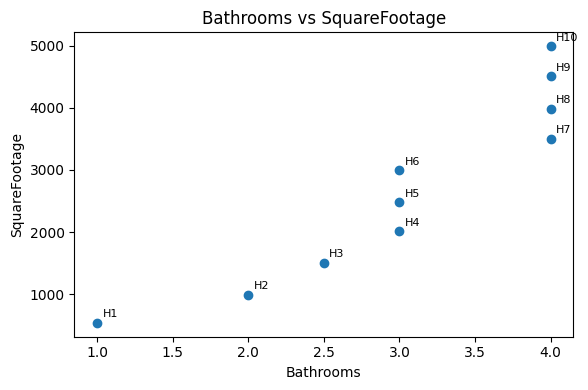

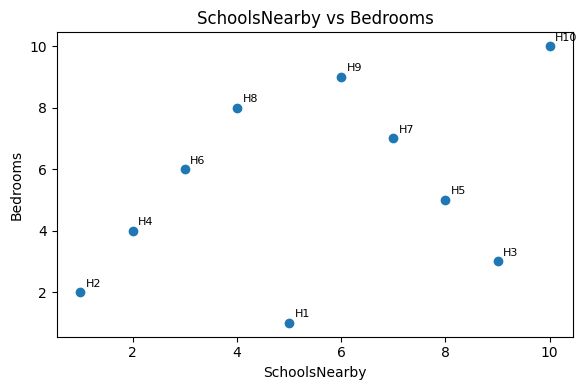

In [4]:

pairs = [
    ("Bedrooms", "Bathrooms"),
    ("Bathrooms", "SquareFootage"),
    ("SchoolsNearby", "Bedrooms")
]

for x, y in pairs:
    plt.figure(figsize=(6, 4))
    plt.scatter(data[x], data[y])
    
    for i, row in data.iterrows():
        plt.annotate(f"H{i+1}", (row[x], row[y]),
                     xytext=(4,4), textcoords="offset points", fontsize=8)
    
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.tight_layout()
    plt.show()


## 2.5 Standardize the numeric features
(Secret step that's important but not THAAAT important and is really just about taking a bunch of averages to get all of the data on the same "scale".) 

In [5]:
features = ["Bedrooms", "Bathrooms", "SquareFootage", "SchoolsNearby", "CrimeRate"]
X = data[features]

scaler = StandardScaler()
Z = scaler.fit_transform(X)

labels = [f"H{i+1}" for i in range(len(data))]

pd.DataFrame(Z, columns=features, index=labels).round(2)

,Bedrooms,Bathrooms,SquareFootage,SchoolsNearby,CrimeRate
H1,-1.57,-2.13,-1.55,-0.17,0.17
H2,-1.22,-1.09,-1.23,-1.57,1.57
H3,-0.87,-0.57,-0.87,1.22,-1.22
H4,-0.52,-0.05,-0.51,-1.22,1.22
H5,-0.17,-0.05,-0.19,0.87,-0.87
H6,0.17,-0.05,0.17,-0.87,0.87
H7,0.52,0.99,0.53,0.52,-0.52
H8,0.87,0.99,0.87,-0.52,0.52
H9,1.22,0.99,1.23,0.17,-0.17
H10,1.57,0.99,1.57,1.57,-1.57


## 3. Computing the Covariance Matrix.

In [6]:
cov_matrix = np.cov(Z, rowvar=False)

print("Covariance matrix of standardized data:")
print(pd.DataFrame(cov_matrix, index=data.columns, columns=data.columns))
print()

Covariance matrix of standardized data:
               Bedrooms  Bathrooms  SquareFootage  SchoolsNearby  CrimeRate
Bedrooms       1.111111   1.037109       1.111051       0.437710  -0.437710
Bathrooms      1.037109   1.111111       1.035497       0.352416  -0.352416
SquareFootage  1.111051   1.035497       1.111111       0.437870  -0.437870
SchoolsNearby  0.437710   0.352416       0.437870       1.111111  -1.111111
CrimeRate     -0.437710  -0.352416      -0.437870      -1.111111   1.111111



## 4. Computing the eigenvectors and eigenvalues of the COV matrix. The eigenvectors are our principal components. 

In [7]:
# -----------------------------
# STEP 4: Eigen decomposition
# -----------------------------
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues (largest → smallest):")
display(pd.Series(eigenvalues, index=[f"PC{i+1}" for i in range(len(eigenvalues))]))
print()

print("Eigenvectors (columns = PCs):")
display(pd.DataFrame(
    eigenvectors,
    index=data.columns,
    columns=[f"PC{i+1}" for i in range(len(eigenvalues))]
))

Eigenvalues (largest → smallest):


PC1    3.852613e+00
PC2    1.607775e+00
PC3    9.511685e-02
PC4    5.088992e-05
PC5   -1.498130e-17
dtype: float64


Eigenvectors (columns = PCs):


,PC1,PC2,PC3,PC4,PC5
Bedrooms,-0.500311,0.285729,0.403341,-0.710890,-1.331841e-13
Bathrooms,-0.473561,0.338520,-0.813068,0.008031,1.257324e-15
SquareFootage,-0.500143,0.285270,0.417020,0.703258,1.319614e-13
SchoolsNearby,-0.371003,-0.600992,-0.034135,0.000179,7.071068e-01
CrimeRate,0.371003,0.600992,0.034135,-0.000179,7.071068e-01


## 5. Computing the explained variance 

In [8]:
# -----------------------------
# STEP 5: Explained variance
# -----------------------------
explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)

ev_df = pd.DataFrame({
    "Eigenvalue": eigenvalues,
    "Explained Variance Ratio": explained,
    "Cumulative Explained Variance": cumulative
}, index=[f"PC{i+1}" for i in range(len(eigenvalues))])

display(ev_df.round(4))

,Eigenvalue,Explained Variance Ratio,Cumulative Explained Variance
PC1,3.8526,0.6935,0.6935
PC2,1.6078,0.2894,0.9829
PC3,0.0951,0.0171,1.0000
PC4,0.0001,0.0000,1.0000
PC5,-0.0000,-0.0000,1.0000


## 6. The data in principal component coordinates followed by a plot of the data in PC1 vs PC2 space.

In [9]:
# -----------------------------
# STEP 6 A: Project data
# -----------------------------
scores = Z @ P

scores_df = pd.DataFrame(
    scores,
    index=[f"H{i+1}" for i in range(scores.shape[0])],
    columns=[f"PC{i+1}" for i in range(scores.shape[1])]
)

print("Data in the Principal Component coordinates:")
display(scores_df.round(3))

NameError: name 'P' is not defined

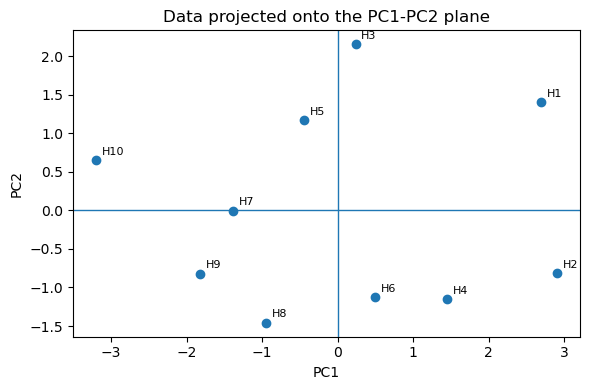

In [21]:
# -----------------------------
# STEP 6 B: Plot the data in the PC1-PC2 plane
# -----------------------------
scores = Z @ P

scores_df = pd.DataFrame(
    scores,
    columns=[f"PC{i+1}" for i in range(scores.shape[1])]
)

plt.figure(figsize=(6, 4))
plt.scatter(scores_df["PC1"], scores_df["PC2"])

for i in range(len(scores_df)):
    plt.annotate(f"H{i+1}",
                 (scores_df.loc[i, "PC1"], scores_df.loc[i, "PC2"]),
                 xytext=(4, 4),
                 textcoords="offset points",
                 fontsize=8)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data projected onto the PC1-PC2 plane")
plt.tight_layout()
plt.show()